<a href="https://colab.research.google.com/github/BrunoASNascimento/BrunoASNascimento/blob/master/pluvion_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import datetime


In [ ]:
dados = pd.read_csv('base_data.csv',sep=',')
dados = dados.dropna(axis=1, how='any')
dados = dados[(dados['forecastType'] == 'HD5D') & (dados['stationHWID'] == 'A02') & ( dados['pc_obs'] != 0) & (dados['pc_prev'] != 0)]
dados['forecastDate'] = pd.to_datetime(dados['forecastDate'], format='%Y-%m-%d %H:%M:%S')
dados['hour'] = pd.to_datetime(dados['hour'], format='%Y-%m-%d %H:%M:%S')
dados['month'] = dados['hour'].dt.date
dados['delta_date'] = (dados['hour']-dados['forecastDate']).dt.days
dados = dados[(dados['delta_date']<=0)]
dados = dados.sort_values(['ps_prev', 'tp_prev'],ascending=[False,True])

In [ ]:
dados.dtypes

forecastType            object
stationHWID             object
forecastDate    datetime64[ns]
hour            datetime64[ns]
ps_prev                float64
rh_prev                float64
tp_prev                float64
tc_prev                float64
rd_prev                float64
ws_prev                float64
pc_prev                float64
pc_obs                 float64
month                   object
delta_date               int64
dtype: object

In [ ]:
dados.head()

,forecastType,stationHWID,forecastDate,hour,ps_prev,rh_prev,tp_prev,tc_prev,rd_prev,ws_prev,pc_prev,pc_obs,month,delta_date
13673,HD5D,A02,2019-04-23 03:00:00,2019-04-23 23:00:00,1017.59,79.4,24.28,1.0,0.00,1.78,0.02,0.2,2019-04-23,0
9785,HD5D,A02,2019-04-10 03:00:00,2019-04-11 02:00:00,1017.10,95.7,21.72,1.0,0.00,1.32,8.92,2.2,2019-04-11,0
9303,HD5D,A02,2019-04-09 03:00:00,2019-04-09 23:00:00,1016.33,84.3,22.69,1.0,0.00,1.78,0.22,0.8,2019-04-09,0
9248,HD5D,A02,2019-04-09 03:00:00,2019-04-09 15:00:00,1016.26,93.1,22.82,1.0,141.23,3.44,8.24,0.8,2019-04-09,0
13657,HD5D,A02,2019-04-23 03:00:00,2019-04-23 19:00:00,1016.18,84.9,25.19,1.0,69.41,0.72,1.14,1.2,2019-04-23,0


In [ ]:
dados.to_csv('test.csv')

NameError: ignored

In [ ]:
max(dados['pc_obs'])

109.8

In [ ]:
dados.shape

(149, 14)

In [ ]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'pc_prev')

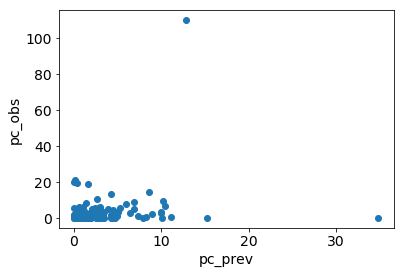

In [ ]:
plt.rcParams.update({'font.size': 14})
plt.scatter(dados['pc_prev'],dados['pc_obs'])
plt.ylabel('pc_obs')
plt.xlabel('pc_prev')

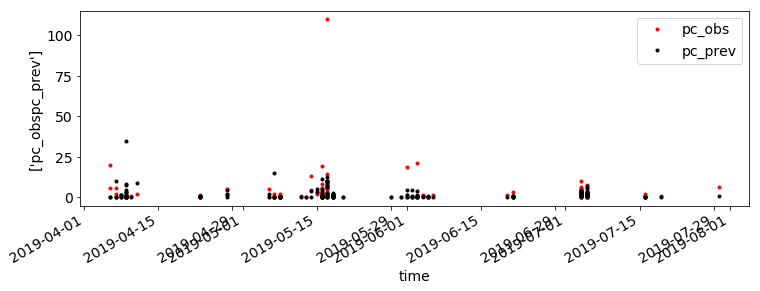

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(dados['month'],dados['pc_obs'],'.r')
plt.plot(dados['month'],dados['pc_prev'],'.k')
plt.legend(['pc_obs','pc_prev'])
plt.ylabel(['pc_obs''pc_prev'])
plt.xlabel('time')

plt.gcf().autofmt_xdate()
plt.savefig('pc_obs_x_pc_prev_inicial.png')
plt.show()

In [ ]:
import numpy as np

In [ ]:
y = dados[ 
          'pc_obs'].values

In [ ]:
X = dados[
          [           
           
          'ps_prev',		'tp_prev',	'tc_prev',	'rd_prev',	'ws_prev',	'pc_prev','rh_prev'
    ]
    ].values
print(X)

[[1.01759e+03 2.42800e+01 1.00000e+00 ... 1.78000e+00 2.00000e-02
  7.94000e+01]
 [1.01710e+03 2.17200e+01 1.00000e+00 ... 1.32000e+00 8.92000e+00
  9.57000e+01]
 [1.01633e+03 2.26900e+01 1.00000e+00 ... 1.78000e+00 2.20000e-01
  8.43000e+01]
 ...
 [9.95600e+02 2.17700e+01 1.00000e+00 ... 1.88000e+00 1.20000e+00
  8.33000e+01]
 [9.94400e+02 2.15300e+01 1.00000e+00 ... 1.00000e+00 1.40000e+00
  8.81000e+01]
 [9.94100e+02 2.23800e+01 1.00000e+00 ... 2.06000e+00 1.60000e+00
  7.69000e+01]]


In [ ]:
X = X/np.amax(X,axis=0)
print(X, len(X))

[[1.00000000e+00 8.28103683e-01 1.00000000e+00 ... 2.31168831e-01
  5.73888092e-04 8.00403226e-01]
 [9.99518470e-01 7.40791269e-01 1.00000000e+00 ... 1.71428571e-01
  2.55954089e-01 9.64717742e-01]
 [9.98761780e-01 7.73874488e-01 1.00000000e+00 ... 2.31168831e-01
  6.31276901e-03 8.49798387e-01]
 ...
 [9.78390118e-01 7.42496589e-01 1.00000000e+00 ... 2.44155844e-01
  3.44332855e-02 8.39717742e-01]
 [9.77210861e-01 7.34311050e-01 1.00000000e+00 ... 1.29870130e-01
  4.01721664e-02 8.88104839e-01]
 [9.76916047e-01 7.63301501e-01 1.00000000e+00 ... 2.67532468e-01
  4.59110473e-02 7.75201613e-01]] 149


In [ ]:
ymax=np.amax(y)
y = y/ymax
print(y, len (y))

[0.00182149 0.02003643 0.00728597 0.00728597 0.01092896 0.00182149
 0.01639344 0.00910747 0.00364299 0.00364299 0.02367942 0.00182149
 0.00182149 0.00728597 0.00364299 0.00182149 0.00364299 0.01639344
 0.01275046 0.01821494 0.18214936 0.00364299 0.00182149 0.00182149
 0.04553734 0.05282332 0.01821494 0.05464481 0.00728597 0.01457195
 0.00182149 0.00182149 0.03278689 0.00546448 0.00364299 0.00910747
 0.00182149 0.00182149 0.01275046 1.         0.05282332 0.13296903
 0.17850638 0.00728597 0.01275046 0.01821494 0.00728597 0.02550091
 0.04918033 0.0856102  0.01639344 0.08014572 0.06010929 0.02550091
 0.03278689 0.00182149 0.01275046 0.01092896 0.00546448 0.00182149
 0.03460838 0.0273224  0.04553734 0.00910747 0.00182149 0.02003643
 0.04735883 0.0564663  0.00182149 0.01092896 0.02185792 0.00182149
 0.00546448 0.00364299 0.02003643 0.07650273 0.03096539 0.01275046
 0.00910747 0.00728597 0.01275046 0.01457195 0.00182149 0.00364299
 0.00364299 0.00728597 0.01821494 0.00182149 0.00182149 0.0036

In [ ]:
def sigmoid(Soma):
    return 1/(1+np.exp(-Soma))

def relu(Soma):
    return np.maximum(0,Soma)

In [ ]:
arquitetura = [
    {"dim_entrada": 7, "dim_saida": 100, "ativacao": "relu"},
    {"dim_entrada": 100, "dim_saida": 1000, "ativacao": "relu"},
    {"dim_entrada": 1000, "dim_saida": 100, "ativacao": "relu"},    
    {"dim_entrada": 100, "dim_saida": 200, "ativacao": "relu"},
    {"dim_entrada": 200, "dim_saida": 1, "ativacao": "sigmoid"},
    
]

In [ ]:
def inicia_camadas(arquitetura, seed = 99):
    # inicia os valores aleatórios
    np.random.seed(seed)
    # numero de camadas da rede neural
    numero_de_camadas = len(arquitetura)
    # inicia armazenamento de parametros
    valores_parametros = {}
    
    # itera nas camadas da rede
    for indice, camada in enumerate(arquitetura):
        
        indice_camada = indice + 1
        
        # extrai o numero de nodos nas camadas
        tamanho_camada_entrada = camada["dim_entrada"]
        tamanho_camada_saida = camada["dim_saida"]
        
        # inicia os valores na matriz de pesos P
        # e o vetor de viés ou bias b
        valores_parametros['P' + str(indice_camada)] = np.random.randn(
            tamanho_camada_saida, tamanho_camada_entrada)  * 0.1
        valores_parametros['b' + str(indice_camada)] = np.random.randn(
            tamanho_camada_saida, 1) * 0.1
        
    return valores_parametros

In [ ]:
def propaga_uma_camada(Ativado_anterior, Pesos_atual, b_atual, ativacao="relu"):
    # cálculo da entrada para a função de ativação
    Saida_atual = np.dot(Pesos_atual, Ativado_anterior) + b_atual
    
    # selecção da função de ativação
    if ativacao is "relu":
        func_ativacao = relu
    elif ativacao is "sigmoid":
        func_ativacao = sigmoid
    else:
        raise Exception('Ainda não implementamos essa funcao')
        
    # retorna a ativação calculada Ativado_atual e a matriz intermediária Saida
    return func_ativacao(Saida_atual), Saida_atual

In [ ]:
def propaga_total(X, valores_parametros, arquitetura):
    # memoria temporaria para a retropropagacao
    memoria = {}
    # O vetor X é a ativação para a camada 0 
    Ativado_atual = X
    
    # iterações para as camadas
    for indice, camada in enumerate(arquitetura):
        # a numeração das camadas começa de 1
        indice_camada = indice + 1
        # utiliza a ativação da iteração anterior
        Ativado_anterior = Ativado_atual
        
        # extrai a função de ativação para a camada atual
        func_ativacao_atual = camada["ativacao"]
        # extrai os pesos da camada atual
        Pesos_atual = valores_parametros["P" + str(indice_camada)]
        # extrai o bias para a camada atual
        b_atual = valores_parametros["b" + str(indice_camada)]
        # cálculo da ativação para a camada atual
        Ativado_atual, Saida_atual = propaga_uma_camada(Ativado_anterior, Pesos_atual, b_atual, func_ativacao_atual)
        
        # salca os valores calculados na memória
        memoria["A" + str(indice)] = Ativado_anterior
        memoria["Z" + str(indice_camada)] = Saida_atual
       
    # retorna o vetor predito e um dicionário contendo os valores intermediários
    return Ativado_atual, memoria

In [ ]:
valores_parametros = inicia_camadas(arquitetura, seed = 99)
y_estimado, memoria = propaga_total(np.transpose(X), valores_parametros, arquitetura)

In [ ]:
y_estimado[0,0]*ymax

57.49568835389418

In [ ]:
y[0]*ymax

0.2

In [ ]:
def atualiza(valores_parametros, gradidentes, arquitetura, taxa_aprendizagem):

    # iterações pelas camadas
    for indice_camada, camada in enumerate(arquitetura, 1):
        valores_parametros["P" + str(indice_camada)] -= taxa_aprendizagem * gradidentes["dP" + str(indice_camada)]        
        valores_parametros["b" + str(indice_camada)] -= taxa_aprendizagem * gradidentes["db" + str(indice_camada)]

    return valores_parametros;

In [ ]:
def valor_de_custo(Y_predito, Y):
    # numero_de_exemplos
    m = Y_predito.shape[1]
    
    custo = -1 / m * (np.dot(Y, np.log(Y_predito).T) + np.dot(1 - Y, np.log(1 - Y_predito).T))
    return np.squeeze(custo)

In [ ]:
def retropropagacao_total(Y_predito, Y, memoria, valores_parametros, arquitetura):
   
    gradientes = {}
    
    # numero de exemplos
    #m = Y.shape[1]
    # para garantir que os dois vetores tenham a mesma dimensão
    Y = Y.reshape(Y_predito.shape)
    
    # inicia o algoritmo de gradiente descendente
    dAtivado_anterior = - (np.divide(Y, Y_predito) - np.divide(1 - Y, 1 - Y_predito));
    
    for indice_camada_anterior, camada in reversed(list(enumerate(arquitetura))):
        
        indice_camada_atual = indice_camada_anterior + 1
        # Função de ativação para a camada atual
        
        funcao_ativao_atual = camada["ativacao"]
        
        dAtivado_atual = dAtivado_anterior
        
        Ativado_anterior = memoria["A" + str(indice_camada_anterior)]
        Saida_atual = memoria["Z" + str(indice_camada_atual)]
        
        Pesos_atual = valores_parametros["P" + str(indice_camada_atual)]
        b_atual = valores_parametros["b" + str(indice_camada_atual)]
        
        dAtivado_anterior, dPesos_atual, db_atual = retropropagacao_uma_camada(
            dAtivado_atual, Pesos_atual, b_atual, Saida_atual, Ativado_anterior, funcao_ativao_atual)
        
        gradientes["dP" + str(indice_camada_atual)] = dPesos_atual
        gradientes["db" + str(indice_camada_atual)] = db_atual
    
    return gradientes

In [ ]:
def sigmoid_retro(dAtivado, Saida):
    sig = sigmoid(Saida)
    return dAtivado * sig * (1 - sig)

def relu_retro(dAtivado, Saida):
    dSaida = np.array(dAtivado, copy = True)
    dSaida[Saida <= 0] = 0;
    return dSaida;

In [ ]:
def retropropagacao_uma_camada(dAtivado_atual, Pesos_atual, b_atual, Saida_atual, Ativado_anterior, ativacao="relu"):
    # número de exemplos
    m = Ativado_anterior.shape[1]
    
    # seleção função de ativação
    if ativacao is "relu":
        func_ativacao_retro = relu_retro
    elif ativacao is "sigmoid":
        func_ativacao_retro = sigmoid_retro
    else:
        raise Exception('Ainda não implementamos essa funcao')
    
    # derivada da função de ativação
    dSaida_atual = func_ativacao_retro(dAtivado_atual, Saida_atual)
    
    # derivada da matriz de Pesos
    dPesos_atual = np.dot(dSaida_atual, Ativado_anterior.T) / m
    # derivada do vetor b
    db_atual = np.sum(dSaida_atual, axis=1, keepdims=True) / m
    # derivada da matriz A_anterior
    dAtivado_anterior = np.dot(Pesos_atual.T, dSaida_atual)

    return dAtivado_anterior, dPesos_atual, db_atual

In [ ]:
def treino(X, Y,X_teste,Y_teste, arquitetura, epocas, taxa_aprendizagem):
    # Inicia os parâmetros da rede neural
    valores_parametros = inicia_camadas(arquitetura, 2)
    # Listas que vão guardar o progresso da aprendizagem da rede 
    historia_custo = []
    historia_custo_teste = []
   
    
    # Atualiza a cada época
    for i in range(epocas):
        # Propaga a rede - Foward propagation
        Y_predito, memoria = propaga_total(X, valores_parametros, arquitetura)
        
        Y_predito_teste, memoria2 = propaga_total(X_teste, valores_parametros, 
                                                  arquitetura)
        
        # calcula as métricas e salva nas listas de história
        custo = valor_de_custo(Y_predito, Y)
        historia_custo.append(custo)
        custo_teste = valor_de_custo(Y_predito_teste, Y_teste)
        historia_custo_teste.append(custo_teste)
        
        
        # Retropropagação - Backpropagation
        gradientes = retropropagacao_total(Y_predito, Y, memoria, 
                                           valores_parametros, arquitetura)
        # Atualiza os pesos
        valores_parametros = atualiza(valores_parametros, gradientes, 
                                      arquitetura, taxa_aprendizagem)
        
        if(i % 100 == 0):
            
            print("Iteração: {:05} - custo: {:.5f} ".format(i, custo))
            
            
    return valores_parametros, historia_custo, historia_custo_teste

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split( X, y, test_size=0.43, random_state=42)

In [ ]:
# Treinamento
valores_parametros, historia_custo, historia_custo_teste = treino(np.transpose(X_treino), np.transpose(y_treino.reshape((y_treino.shape[0], 1))), 
                                                                  np.transpose(X_teste), np.transpose(y_teste.reshape((y_teste.shape[0], 1))), 
                                                                  arquitetura, 4500, 0.01)

Iteração: 00000 - custo: 0.45099 
Iteração: 00100 - custo: 0.14450 
Iteração: 00200 - custo: 0.14369 
Iteração: 00300 - custo: 0.14321 
Iteração: 00400 - custo: 0.14282 
Iteração: 00500 - custo: 0.14246 
Iteração: 00600 - custo: 0.14213 
Iteração: 00700 - custo: 0.14183 
Iteração: 00800 - custo: 0.14153 
Iteração: 00900 - custo: 0.14124 
Iteração: 01000 - custo: 0.14091 
Iteração: 01100 - custo: 0.14062 
Iteração: 01200 - custo: 0.14035 
Iteração: 01300 - custo: 0.14007 
Iteração: 01400 - custo: 0.13979 
Iteração: 01500 - custo: 0.13951 
Iteração: 01600 - custo: 0.13922 
Iteração: 01700 - custo: 0.13892 
Iteração: 01800 - custo: 0.13860 
Iteração: 01900 - custo: 0.13826 
Iteração: 02000 - custo: 0.13790 
Iteração: 02100 - custo: 0.13754 
Iteração: 02200 - custo: 0.13716 
Iteração: 02300 - custo: 0.13678 
Iteração: 02400 - custo: 0.13638 
Iteração: 02500 - custo: 0.13597 
Iteração: 02600 - custo: 0.13556 
Iteração: 02700 - custo: 0.13515 
Iteração: 02800 - custo: 0.13473 
Iteração: 0290

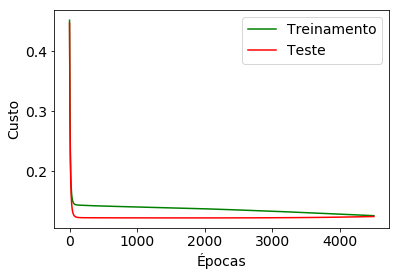

In [ ]:
plt.plot(historia_custo,'g')
plt.plot(historia_custo_teste, 'r')
plt.legend(['Treinamento','Teste'])
plt.ylabel('Custo')
plt.xlabel('Épocas')
plt.savefig('curva_de_treinamento.png')
plt.show()

In [ ]:
# Previsão
Y_pred, _ = propaga_total(np.transpose(X_teste), valores_parametros, arquitetura)

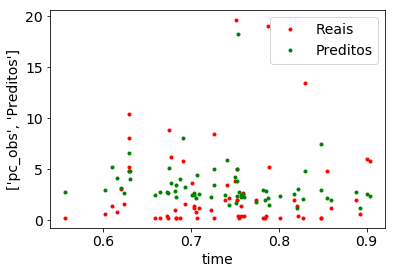

In [ ]:
plt.plot(np.transpose(X_teste)[1],ymax*y_teste,'.r')
plt.plot(np.transpose(X_teste)[1],ymax*Y_pred.reshape([-1,1]),'.g')
plt.legend(['Reais','Preditos'])
plt.ylabel(['pc_obs','Preditos'])
plt.xlabel('time')
plt.savefig('pc_obs_x_pc_prev_final.png')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import f1_score

In [ ]:
prev = []
real = []
for i in ymax*Y_pred.reshape([-1,1]):
    prev.append(i[0])
for i in ymax*y_teste:
    real.append(i)

In [ ]:
dados['error'] = abs(dados['pc_prev'] - dados['pc_obs'])
dados['error'] = dados['error']/dados['pc_obs']
inicial = sum(dados['error'])/len(dados['error'])
inicial

3.4414152496160453

In [ ]:
erro = abs(np.array(prev)-np.array(real))
final = sum(erro)/len(erro)
final

2.8486839051804105

In [ ]:
1-(final/inicial)

0.17223476431731544